#### Integer factorization
Input:  an integer $N\geq 2$\
Output: the prime factorization of $N$

In [1]:
import math
from sympy.ntheory import factorint

In [2]:
N = 12
print(factorint(N))

{2: 2, 3: 1}


In [4]:
# RSA10124 has 309 decimal digits (or 1024 bits when written in binary).
RSA1024 = 135066410865995223349603216278805969938881475605667027524485143851526510604859533833940287150571909441798207282164471551373680419703964191743046496589274256239341020864383202110372958725762358509643110564073501508187510676594629205563685529475213500852879416377328533906109750544334999811150056977236890927563
print(factorint(RSA1024))

KeyboardInterrupt: 

The fastest known algorithm for factoring large integers is known as the number field sieve.

In [5]:
# RSA250 has 250 decimal digits (or 829 bits when written in binary).
RSA250 = 2140324650240744961264423072839333563008614715144755017797754920881418023447140136643345519095804679610992851872470914587687396261921557363047454770520805119056493106687691590019759405693457452230589325976697471681738069364894699871578494975937497937
 
p = 64135289477071580278790190170577389084825014742943447208116859632024532344630238623598752668347708737661925585694639798853367
q = 33372027594978156556226010605355114227940760344767554666784520987023841729210037080257448673296881877565718986258036932062711
 
print(RSA250 == p * q)

True


#### Greatest common divisor (GCD)

Input: nonnegative integers $N$ and $M,$ at least one of which is positive\
Output: the greatest common divisor of $N$ and $M$

This problem is easy to solve with a computer — it has roughly the same computational cost as multiplying the two input numbers together.

In [6]:
N = 4636759690183918349682239573236686632636353319755818421393667064929987310592347460711767784882455889983961546491666129915628431549982893638464243493812487979530329460863532041588297885958272943021122033997933550246447236884738870576045537199814804920281890355275625050796526864093092006894744790739778376848205654332434378295899591539239698896074
M = 5056714874804877864225164843977749374751021379176083540426461360945653967249306494545888621353613218518084414930846655066495767441010526886803458300440345782982127522212209489410315422285463057656809702949608368597012967321172325810519806487247195259818074918082416290513738155834341957254558278151385588990304622183174568167973121179585331770773
 
print(math.gcd(N, M))

135066410865995223349603216278805969938881475605667027524485143851526510604859533833940287150571909441798207282164471551373680419703964191743046496589274256239341020864383202110372958725762358509643110564073501508187510676594629205563685529475213500852879416377328533906109750544334999811150056977236890927563


This is possible because we have very efficient algorithms for computing GCDs, the most well-known of which is Euclid's algorithm

## Measuring computational cost

#### Encodings and input length

The number of bits required to express a nonnegative integer $N$ in binary notation is given by the following formula.

$$
\operatorname{lg}(N) =
\begin{cases}
1 & N = 0\\
1 + \lfloor \log_2 (N) \rfloor & N \geq 1
\end{cases}
$$

sign bit and leading zeros

| Number | Unary encoding | Lexicographic encoding | Binary encoding |
| :----- | :------------- | :--------------------- | :-------------- |
| 0      | $\varepsilon$  | $\varepsilon$          | 0               |
| 1      | 0              | 0                      | 1               |
| 2      | 00             | 1                      | 10              |
| 3      | 000            | 00                     | 11              |
| 4      | 0000           | 01                     | 100             |
| 5      | 00000          | 10                     | 101             |
| 6      | 000000         | 11                     | 110             |
| 7      | 0000000        | 000                    | 111             |
| 8      | 00000000       | 001                    | 1000            |

back and forth conversion - negligible cost

input length

#### Elementary operations
To measure computational cost is to count the number of elementary operations that each computation requires. 

Intuitively speaking, an elementary operation is one involving a small, fixed number of bits or qubits, that can be performed quickly and easily — such as computing the AND of two bits.

Focusing for the moment on quantum circuits, we've $X,$ $Y,$ $Z,$ $H,$ $S,$ and $T$ gates, *swap* gates, controlled versions of gates (including *controlled-NOT*, *Toffoli*, and *Fredkin* gates), as well as gates that represent standard basis measurements.
In the context of the CHSH game we also saw a few additional *rotation* gates.

A standard quantum gate set
*   Single-qubit unitary gates from this list: $X,$ $Y,$ $Z,$ $H,$ $S,$ $S^{\dagger},$ $T,$ and $T^{\dagger}$
*   Controlled-NOT gates
*   Single-qubit standard basis measurements

For Boolean circuits, we'll take AND, OR, NOT, and FANOUT gates to be the ones representing elementary operations.

#### The principle of deferred measurement
<img src="./images/deferred-measurement.svg" width = "500">


#### Circuit size
A circuit's size represents the number of elementary operations or gates it requires — or, in other words, its computational cost. - sequential running time

#### Circuit depth
A different way to measure the efficiency of circuits, which takes this possibility of parallelization into account, is by their depth. 

This is the minimum number of layers of gates needed within the circuit, where the gates within each layer operate on different wires. - parallel running time

<img src="./images/Boolean-circuit-XOR.svg" width="300"> \
The size of this circuit is 7 because there are 7 gates in total. \
The deapth is 4.

#### Families of circuits

An algorithm in the Boolean circuit model is described by a sequence of circuits
$\{C_1, C_2, C_3,\ldots\},$ where $C_n$ solves problem for $n$-bit inputs (or, more generally, for inputs whose size is parameterized in some way by $n$), and the function $t$ representing the cost of this algorithm is defined as

$$
t(n) = \operatorname{size}(C_n).
$$

#### Integer Addition
Input: integers $N$ and $M$\
Output: $N+M$

$$
0\leq N,M\leq 2^n - 1.
$$

<img src="./images/half-adder.svg" width="300"> \
Using the XOR circuit we've now seen a few times together with an AND gate and two FANOUT gates, we can build a half adder with 10 gates. 

<img src="./images/full-adder.svg" width="500"> \
This requires 21 gates in total: 2 AND gates, 2 XOR gates (each requiring 7 gates to implement), one OR gate, and 4 FANOUT gates.

By cascading the full adders, we obtain a Boolean circuit for nonnegative integer addition. The following circuit computes the sum of two 4-bit integers.

<img src="./images/addition-circuit.svg" width="500"> \

In general, this requires
$$
21 (n-1) + 10 = 21 n - 11
$$

gates. \
Had we decided to include XOR gates in our set of elementary operations, we would need $2n-1$ AND gates, $2n-1$ XOR gates, $n-1$ OR gates, and $4n-2$ FANOUT gates, for a total of $9n-5$ gates.
If in addition we decide not to count FANOUT gates, it's $5n-3$ gates.


### Asymptotic notation

If we have two functions $g(n)$ and $h(n),$ we write that $g(n) = O(h(n))$ if there exists a positive real number $c > 0$ and a positive integer $n_0$ such that

$$
g(n) \leq c\cdot h(n)
$$

for all $n \geq n_0.$
Typically $h(n)$ is chosen to be as simple an expression as possible, so that the notation can be used to reveal the limiting behavior of a function in simple terms.
For example, $17 n^3 - 257 n^2 + 65537 = O(n^3).$

This notation can be extended to functions having multiple arguments in a fairly straightforward way.
For instance, if we have two functions $g(n,m)$ and $h(n,m)$ defined on positive integers $n$ and $m,$ we write that $g(n,m) = O(h(n,m))$ if there exists a positive real number $c > 0$ and a positive integer $k_0$ such that

$$
g(n,m) \leq c\cdot h(n,m)
$$

whenever $n+m \geq k_0.$

#### Integer multiplication

Input: integers $N$ and $M$\
Output: $NM$

If $N$ has $n$ bits and $M$ has $m$ bits, there are Boolean circuits of size $O(nm)$ for multiplying $N$ and $M.$ \
The `Schönhage-Strassen` multiplication algorithm can be used to create Boolean circuits for multiplying two $n$-bit integers at cost $O(n \operatorname{lg}(n) \operatorname{lg}(\operatorname{lg}(n))).$


#### Integer division

Input: integers $N$ and $M\neq0$\
Output: integers $q$ and $r$ satisfying $0\leq r < |M|$ and $N = q M + r$

The cost of integer division is similar to multiplication: if $N$ has $n$ bits and $M$ has $m$ bits, there are Boolean circuits of size $O(nm)$ for solving this problem.

Euclid's algorithm for computing the GCD of an $n$-bit number $N$ and an $m$-bit number $M$ requires Boolean circuits of size $O(nm),$ similar to the standard algorithms for multiplication and division.
Also similar to multiplication and division, there are asymptotically faster GCD algorithms — including ones requiring $O(n(\operatorname{lg}(n))^2 \operatorname{lg}(\operatorname{lg}(n)))$ elementary operations to compute the GCD of two $n$-bit numbers.

#### Integer modular exponentiation

Input: integers $N,$ $K,$ and $M$ with $K\geq 0$ and $M\geq 1$\
Output: $N^K \hspace{1mm} (\text{mod }M)$

By $N^K\hspace{1mm} (\text{mod }M)$ we mean the remainder when $N^K$ is divided by $M,$ meaning the unique integer $r$ satisfying $0\leq r < M$ and $N^K = q M + r$ for some integer $q.$

If $N$ has $n$ bits, $M$ has $m$ bits, and $K$ has $k$ bits, this problem can be solved by Boolean circuits having size $O(k m^2 + nm).$

We can use the *power algorithm* (known alternatively as the *binary method* and *repeated squaring*), which makes use of the binary representation of $K$ to perform the entire computation modulo $M.$
Assuming $N,$ $M,$ and $K$ are all $n$-bit numbers, we obtain an $O(n^3)$ algorithm — or a *cubic* time algorithm.

### Cost of integer factorization

One simple approach to factoring is *trial division,* where an algorithm searches through the list $2,\ldots,\sqrt{N}$ to find a prime factor of an input number $N.$
This requires $O(2^{n/2})$ iterations in the worst case when $N$ is an $n$-bit number.
Each iteration requires a trial division, which means $O(n^2)$ elementary operations for each iteration (using a standard algorithm for integer division).
We end up with circuits of size $O(n^2 2^{n/2}),$ which is *exponential* in the input size $n.$

The number field sieve, for instance, which is an algorithm that makes use of randomness, is generally believed (but not rigorously proven) to require

$$
2^{O(n^{1/3} (\operatorname{lg}(n))^{2/3})}
$$

elementary operations to factor $n$-bit integers with high probability.

### Polynomial versus exponential cost

Classical algorithms for integer addition, multiplication, division, and computing greatest common divisors allow us to solve these problems in the blink of an eye for inputs with thousands of bits.
Addition has *linear* cost while the other three problems have *quadratic* cost (or *subquadratic* cost using asymptotically fast algorithms).
Modular exponentiation is more expensive but can still be done pretty efficiently, with *cubic* cost (or sub-cubic cost using asymptotically fast algorithms).

These are all examples of algorithms having *polynomial* cost, meaning that they have cost $O(n^c)$ for some choice of a fixed constant $c > 0.$
As a rough, first-order approximation, algorithms having polynomial cost are abstractly viewed as representing *efficient* algorithms.

In contrast, known classical algorithms for integer factoring have *exponential* cost.
Sometimes the cost of the number field sieve is described as *sub-exponential* because $n$ is raised to the power $1/3$ in the exponent, but in complexity theory it is more typical to reserve this term for algorithms whose cost is

$$
O\bigl(2^{n^{\varepsilon}}\bigr)
$$

for *every* $\varepsilon > 0.$

*NP-complete* problems are a class of problems not known to (and widely conjectured not to) have polynomial-cost algorithms.

## Classical computations on quantum computers


#### Toffoli 
controlled-controlled-NOT gates

<img src="./images/Toffoli-gate.svg" width="300"> 

$$
\begin{pmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0
\end{pmatrix}
$$

query gates for the AND function
It is possible to construct a Toffoli gate from $H,$ $T,$ $T^{\dagger},$ and CNOT gates.

<img src="./images/build-Toffoli.svg" width=700>

In [29]:
from qiskit import QuantumCircuit

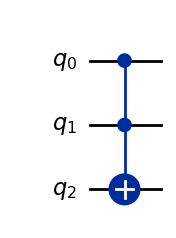

In [ ]:
toffli = QuantumCircuit(3)
toffli.mcx([0, 1], 2)

display(toffli.draw(output='mpl'))      # matplotlib

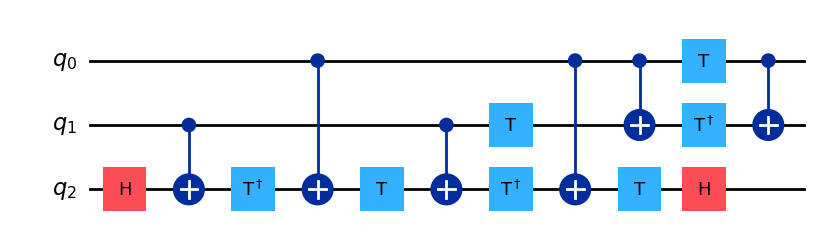

In [25]:
toff = QuantumCircuit(3)
toff.h(2)
toff.cx(1,2)
toff.tdg(2)
toff.cx(0,2)
toff.t(2)
toff.cx(1,2)
toff.tdg(2)
toff.cx(0,2)
toff.t([1,2])
toff.cx(0,1)
toff.t(0)
toff.tdg(1)
toff.h(2)
toff.cx(0,1)

display(toff.draw(output='mpl'))

In [ ]:
# check if the circuits perform the exact same operation.
from qiskit.quantum_info import Operator

op1 = Operator(toffli)
op2 = Operator(toff)

op1.equiv(op2)


True

In [28]:
# checks if both circuits produce the same final state
from qiskit.quantum_info import Statevector

sv1 = Statevector.from_instruction(toffli)
sv2 = Statevector.from_instruction(toff)

sv1.equiv(sv2)

True

#### Simulating Boolean gates with Toffoli, controlled-NOT, and NOT gates

A single Toffoli gate, used in conjunction with a few NOT gates, can implement an AND and OR gate, and FANOUT gates can easily be implemented using controlled-NOT gates

<img src="./images/AND-OR-FANOUT-with-Toffoli.svg" width=700>

For each one we require one workspace qubit initialized to the zero state. These workspace qubits appear inside of the boxes representing the gate implementations to suggest that they're new, and therefore part of the cost of these implementations.

For the AND and OR gates we also have two qubits left over, in addition to the output qubit.

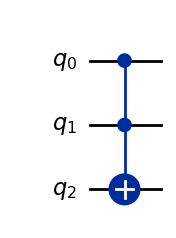

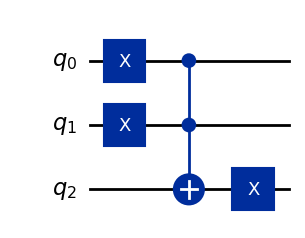

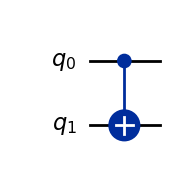

In [34]:
AND = QuantumCircuit(3)
AND.ccx(0, 1, 2)
display(AND.draw(output='mpl'))

OR = QuantumCircuit(3)
OR.x([0, 1])
OR.ccx(0, 1, 2)
OR.x(2)
display(OR.draw(output='mpl'))

FANOUT = QuantumCircuit(2)
FANOUT.cx(0, 1)
display(FANOUT.draw(output='mpl'))

#### Gate by gate simulation of Boolean circuits

Let $t = \operatorname{size}(C)$ be the number of gates in $C,$ and let's give the name $f$ to the function that $C$ computes, which takes the form

$$
f:\Sigma^n\rightarrow\Sigma^m
$$

for $\Sigma = \{0,1\}.$

<img src="./images/reversible-circuit-simulation.svg" width=700>

Here, $k$ is the number of workspace qubits required — one for each AND, OR, and FANOUT gate of $C$ — and $g$ is a function of the form
$g:\Sigma^n \rightarrow \Sigma^{n+k-m}$ that describes the states of the leftover qubits created by the gate simulations after $R$ is run.
In the figure, the qubits corresponding to the output $f(x)$ are on the top and the remaining, leftover qubits storing $g(x)$ are on the bottom.
We can force this to happen if we wish by rearranging the qubits using SWAP gates, which can be implemented with three controlled-NOT gates like this:

<img src = "./images/swap.svg" width = 500>



### Cleaning up the garbage

The phenomenon of interference is critically important to quantum algorithms, and garbage qubits can ruin the interference patterns needed to make quantum algorithms work.

The key is to use the fact that because $R$ is a quantum circuit, we can run it in reverse, by simply replacing each gate with its inverse and applying them in the reverse order, thereby obtaining a quantum circuit for the operation $R^{\dagger}.$
Toffoli gates, CNOT gates, and NOT gates are actually their own inverses, so running $R$ in reverse is really just a matter of applying the gates in the reverse order — but more generally any quantum circuit can be reversed as just described.

Add $m$ more qubits (recalling that the function $f$ has $m$ output bits), use CNOT gates to copy the output of $R$ onto these qubits, and reverse $R$ to clean up the garbage.
The following figure illustrates the resulting circuit and describes its action on standard basis states.

<img src='./images/garbage-free-computation.svg' width = 700>

If we simply want to compute the function $f$ on some string $x,$ we can set $y = 0^m$ and the resulting value $f(x)$ will appear on the bottom $m$ qubits — or we can feed in a different state to the bottom $m$ qubits if we wish
(perhaps to make use of a phase kickback, like in Deutsch's or the Deutsch-Jozsa algorithm).

<img src='./images/simulation-as-query-gate.svg' width=500>



#### Implementing invertible functions

<img src="./images/fully-reversible-simulation.svg" width=700>